In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
import operator


In [3]:
load_dotenv()

True

In [4]:
model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [5]:
class EvaluationSchema(BaseModel):
    feedback:str=Field(description='Detailed feedback fro the essay')
    score:int=Field(description='Score out of 10',ge=0,le=10)
    
    

In [6]:
structured_model=model.with_structured_output(EvaluationSchema)

In [7]:
essay=""" Artificial Intelligence (AI) is one of the most important technologies of the modern world. It enables machines to perform tasks that usually require human intelligence, such as learning, reasoning, problem-solving, and decision-making. AI is widely used in healthcare, education, banking, transportation, agriculture, and business. It helps doctors diagnose diseases, supports students in learning, improves customer service, and automates repetitive tasks. AI also increases productivity, saves time, and reduces human errors. However, it should be used responsibly to protect privacy, ensure fairness, and prevent misuse. With ethical use, AI can improve lives and contribute to a better future for society.  """

In [8]:
prompt=f'Evalute the language quality of the following essay and provide essay and a feedback and assign a acore out of 10 \n {essay}'

In [11]:
structured_model.invoke(prompt)

EvaluationSchema(feedback="The essay demonstrates clear and grammatically correct language throughout. The vocabulary used is appropriate and effectively conveys the key concepts of Artificial Intelligence, its applications, and its benefits. Sentence structures are generally simple and direct, making the essay easy to read and understand. While the language is precise and free of errors, incorporating more varied and complex sentence structures, along with a slightly broader range of vocabulary, could enhance the essay's sophistication and analytical depth. Overall, it's a well-organized and coherent piece that effectively communicates its message.", score=7)

In [35]:
class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_score:Annotated[list[int],operator.add]
    average_score:float

In [36]:
def evalute_language(state:UPSCState):
    prompt=f'Evalute the language quality of the following essay and provide essay and a feedback and assign a acore out of 10 \n {state['essay']}'
    output=structured_model.invoke(prompt)
    
    return {'language_feedback':output.feedback,'individual_score':[output.score]}

In [37]:
def evalute_analysis(state:UPSCState):
    prompt=f'Evalute the language quality of the following essay and provide essay and a feedback and assign a acore out of 10 \n {state['essay']}'
    output=structured_model.invoke(prompt)
    
    return {'analysis_feedback':output.feedback,'individual_score':[output.score]}

In [38]:
def evalute_thought(state:UPSCState):
    prompt=f'Evalute the language quality of the following essay and provide essay and a feedback and assign a acore out of 10 \n {state['essay']}'
    output=structured_model.invoke(prompt)
    
    return {'clarity_feedback':output.feedback,'individual_score':[output.score]}

In [44]:
def final_evaluation(state:UPSCState):
    prompt=f'Based on the following feedback create a summarized feedback \n language feedback-{state["language_feedback"]}\n depth of analysis-{state["analysis_feedback"]}\n clarity of thought feedback-{state["clarity_feedback"]}'
    overall_feedback=model.invoke(prompt).content
    
    average_score=sum(state["individual_score"])/len(state["individual_score"])
    
    return {'overall_feedback':overall_feedback,'average_score':average_score}
    

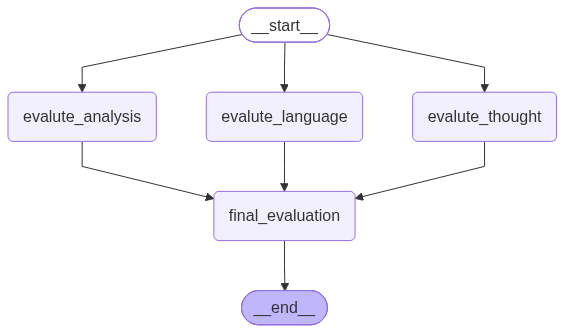

In [45]:
graph = StateGraph(UPSCState)

graph.add_node("evalute_language", evalute_language)
graph.add_node("evalute_analysis", evalute_analysis)
graph.add_node("evalute_thought", evalute_thought)
graph.add_node("final_evaluation", final_evaluation)

graph.add_edge(START, "evalute_language")
graph.add_edge(START, "evalute_analysis")
graph.add_edge(START, "evalute_thought")

graph.add_edge("evalute_language", "final_evaluation")
graph.add_edge("evalute_analysis", "final_evaluation")
graph.add_edge("evalute_thought", "final_evaluation")

graph.add_edge("final_evaluation", END)

workflow = graph.compile()

workflow

In [46]:
initial_state={'essay':essay}
workflow.invoke(initial_state)



{'essay': ' Artificial Intelligence (AI) is one of the most important technologies of the modern world. It enables machines to perform tasks that usually require human intelligence, such as learning, reasoning, problem-solving, and decision-making. AI is widely used in healthcare, education, banking, transportation, agriculture, and business. It helps doctors diagnose diseases, supports students in learning, improves customer service, and automates repetitive tasks. AI also increases productivity, saves time, and reduces human errors. However, it should be used responsibly to protect privacy, ensure fairness, and prevent misuse. With ethical use, AI can improve lives and contribute to a better future for society.  ',
 'language_feedback': "The language quality of the essay is excellent. It is clear, concise, and easy to understand. The vocabulary is appropriate, and the sentences are well-structured, allowing for a smooth flow of ideas. There are no grammatical errors or typos, which c